## Audi Linear Regression

Bootcamp data challenge

In [86]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
# from mpl_toolkits.mplot3d import Axes3D # Needer for 3D representation

In [9]:
audi_df = pd.read_csv('../datasets/audi_challenge.csv')
# audi_df.head()
# audi_df.tail()
audi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7922 entries, 0 to 7921
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            7922 non-null   int64  
 1   car description  7922 non-null   object 
 2   price (euro)     7122 non-null   float64
 3   age (year)       7922 non-null   int64  
 4   fuel type        7922 non-null   object 
 5   transmission     7922 non-null   object 
 6   bodystyle        7922 non-null   object 
 7   car model        7922 non-null   object 
 8   mileage (km)     7922 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 557.1+ KB


### Splitting the data

In [10]:
# Split dataframe into one containing all rows with at least one NaN
audi_df_nan = audi_df[audi_df.isna().any(axis=1)]
audi_df = audi_df.dropna() # Drop rows with at least one NaN

audi_df.tail()

,index,car description,price (euro),age (year),fuel type,transmission,bodystyle,car model,mileage (km)
7117,7117,Audi A3 Limousine | Binnenkort binnen | 30 TFS...,42050.0,0,Petrol,Automatic,Sedan,A3,0
7118,7118,Audi Q2 1.4 TFSI CoD S-tronic Edition #1,48800.0,1,Petrol,Automatic,SUV,Q2,0
7119,7119,Audi A3 Limousine 2.0 TDI Ambition Proline 136...,17300.0,5,Diesel,Manual,Sedan,A3,108716
7120,7120,Audi Q3 2.0 TFSI quattro S Edition Autom Xenon...,27250.0,6,Petrol,Automatic,SUV,Q3,125975
7121,7121,Audi A3 Sportback 1.5 TFSI 150PK S-tronic S li...,38300.0,1,Petrol,Automatic,Hatchback,A3,0


### Stratified sampling

May not be needed

In [18]:
# audi_train_set, audi_test_set = train_test_split(audi_df, test_size=0.2, random_state=42)
# audi_train_set.info()
# audi_test_set.info()

### Data visualisation

Numerical feature:

In [14]:
# car_models = audi_df['car model'].unique() # Extract unique values from 'car models'
# model_mapping = {model: idx for idx, model in enumerate(car_models)}
# audi_df['model_idx'] = audi_df['car model'].map(model_mapping)

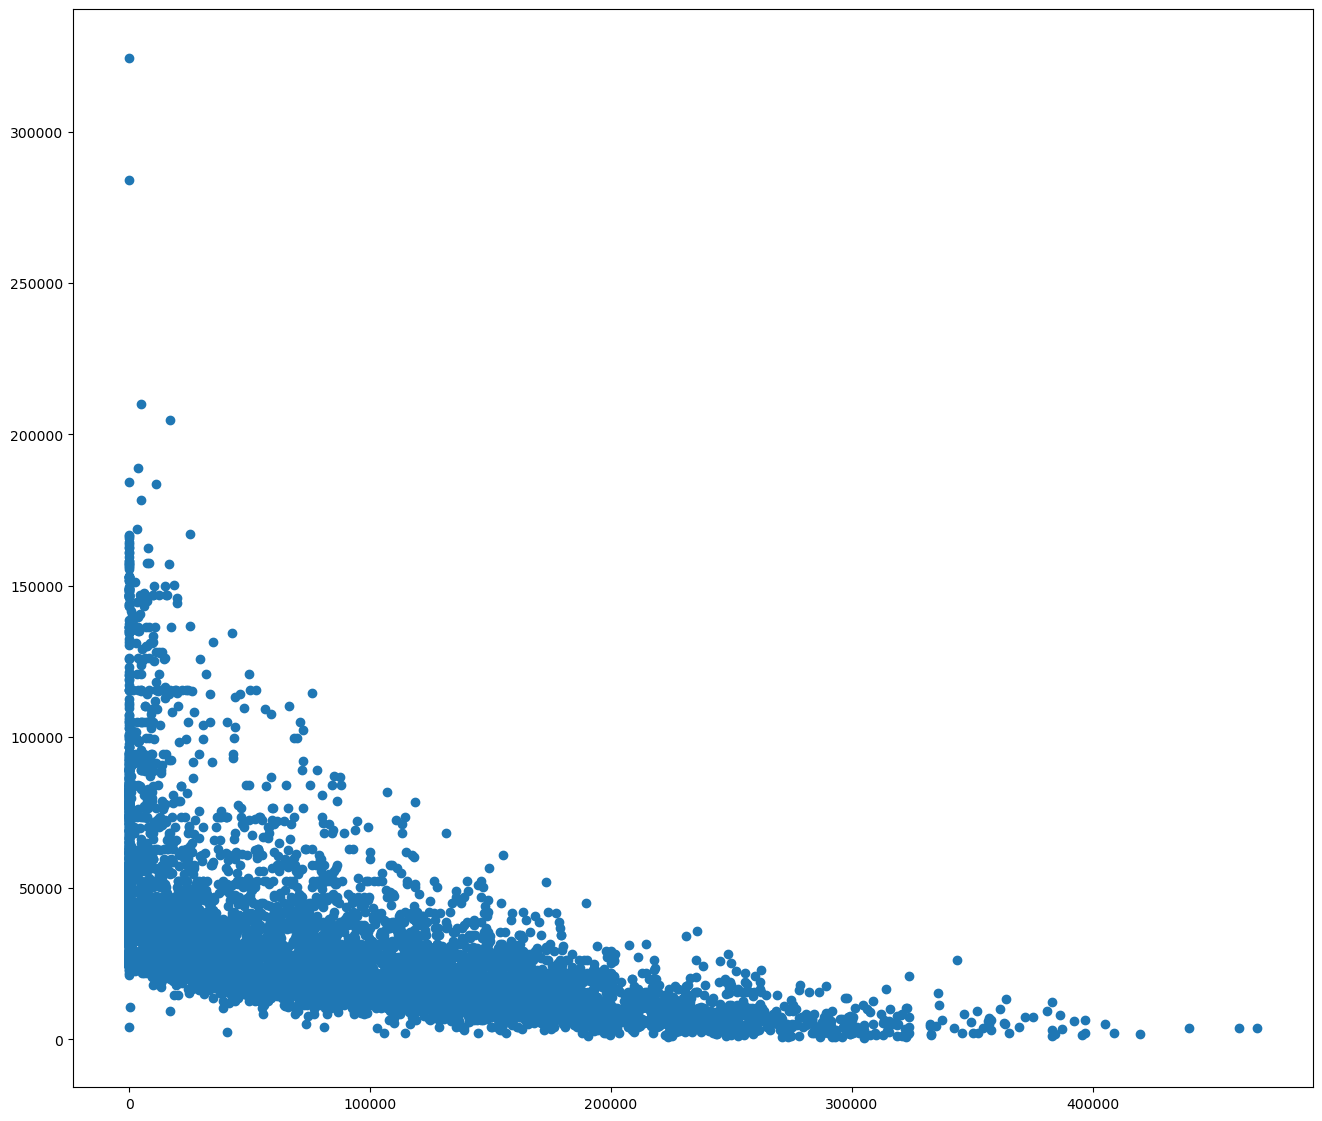

In [35]:
fig = plt.figure(figsize=(16, 14))
plt.scatter(audi_df['mileage (km)'], audi_df['price (euro)'])

ax.set_xlabel('Mileage (km)')
ax.set_zlabel('Price (euro)')
# ax.set_zlabel('Car Model')
# ax.set_zticks(range(len(car_models)))
# ax.set_zticklabels(car_models)

plt.show()

Categorical feature:

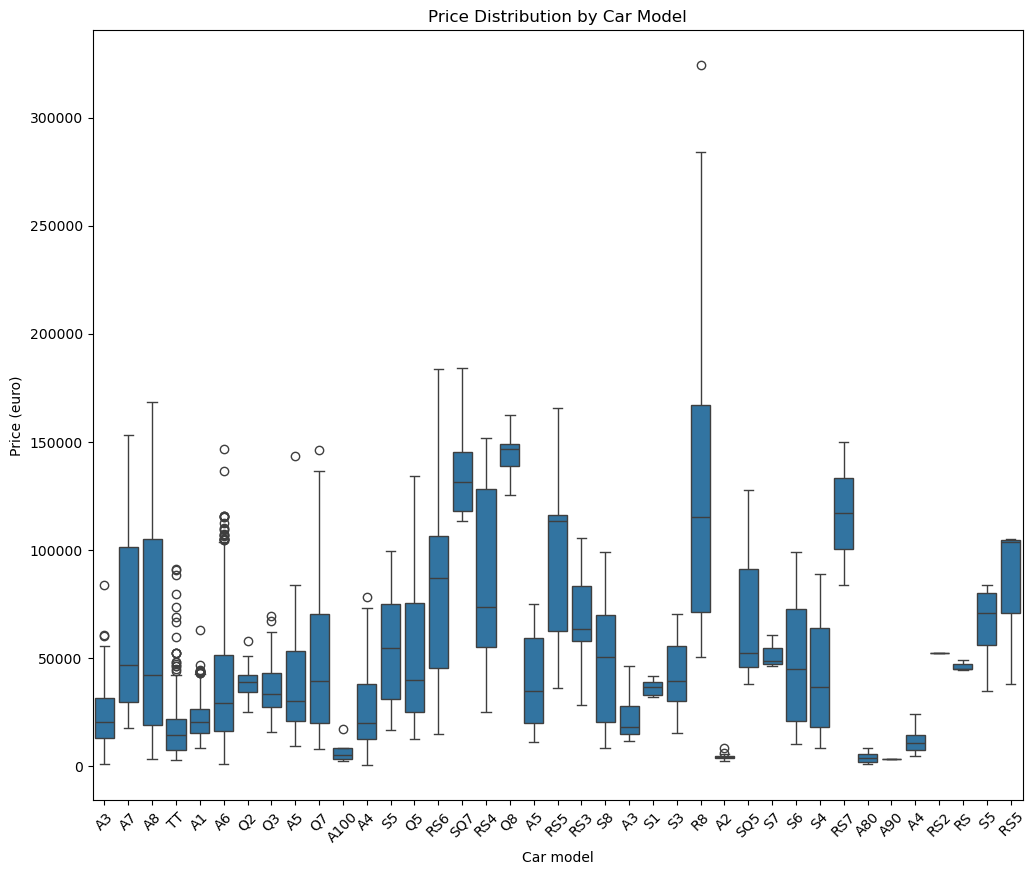

In [59]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=audi_df, x='car model', y='price (euro)')
plt.title('Price Distribution by Car Model')
plt.xlabel('Car model')
plt.ylabel('Price (euro)')
plt.xticks(rotation=45)
plt.show()

### One-hot encoding

One-hot encoding is a method for converting categorical features into binary data (i.e. either true or false). In the below case for the feature 'car model' it will create a new column for each car model and set it to either 1 or 0. For example: 

| index | car model_A1 | car model_A3 |
|---|---|---|
| 324 | 0 | 1 |
| 325 | 1 | 0 |

In [63]:
audi_df_encoded = pd.get_dummies(audi_df, columns=['car model'])
audi_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7122 entries, 0 to 7121
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            7122 non-null   int64  
 1   car description  7122 non-null   object 
 2   price (euro)     7122 non-null   float64
 3   age (year)       7122 non-null   int64  
 4   fuel type        7122 non-null   object 
 5   transmission     7122 non-null   object 
 6   bodystyle        7122 non-null   object 
 7   mileage (km)     7122 non-null   int64  
 8   model_idx        7122 non-null   int64  
 9   car model_ A3    7122 non-null   bool   
 10  car model_ A4    7122 non-null   bool   
 11  car model_ A5    7122 non-null   bool   
 12  car model_ RS5   7122 non-null   bool   
 13  car model_ S5    7122 non-null   bool   
 14  car model_A1     7122 non-null   bool   
 15  car model_A100   7122 non-null   bool   
 16  car model_A2     7122 non-null   bool   
 17  car model_A3     71

### Linear regression model

Mathematically the formula for simple linear regression is:

$y=\beta x_i+\beta_0+\epsilon_i$

where:

- $y$ is the dependent variable (prediction)
- Beta ($\beta$) refers to the coefficients (weights) of the model
- $\beta_0$ (beta nought) is the intercept or bias term
- $\epsilon$ (epsilon) is the error term that accounts for everything not explained by the linear relationship

>$\beta_0$ (beta nought) and $\alpha$ (alpha) are often used interchangeably to represent the intercept (or bias) of the model.

1. https://mbrenndoerfer.com/writing/simple-linear-regression-complete-guide-math-formulas-python-scikit-learn-implementation

In [70]:
def predict(coefficient, bias, x_i):
    return coefficient * x_i + bias

def error(coefficient, bias, x_i, y_i):
    return predict(coefficient, bias, x_i) - y_i

#### Sum of Squared Errors

The formula for the Sum of Squared Errors is defined as:

$SSE=\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$

where:


The SSE calculates the sum of all the differences between the predicted value (from a model) and the actual value. It squares each difference to eliminate negative values (and also penalize larger errors more heavily). The result of this operation is then used to evaluate a models performance or as a function to minimize (e.g. using gradient descent)

In [71]:
# Cost function
# def squared_error(coefficient, bias, x_i, y_i):
#     return (error(coefficient, bias, x_i, y_i)) ** 2

In [138]:
audi_df['mileage (km)'] = audi_df['mileage (km)'] / audi_df['mileage (km)'].max()
audi_df['price (euro)'] = audi_df['price (euro)'] / audi_df['price (euro)'].max()

In [139]:
def predict(coefficient, bias, x_i):
    return coefficient * x_i + bias

def error(coefficient, bias, x_i, y_i):
    return predict(coefficient, bias, x_i) - y_i

In [145]:
iterations = 1000
learning_rate = 0.0001

beta = 0.0# random.random() # Coefficient
alpha = 0.0# random.random() # Intercept

m = len(audi_df['price (euro)'])

def adjust_weights():

    global beta, alpha

    gradient_beta = 0
    gradient_alpha = 0
    
    for i in range(m):
        x_i = audi_df['mileage (km)'][i] # x value
        y_i = audi_df['price (euro)'][i] # y value

        gradient_beta += 2 * error(beta, alpha, x_i, y_i)
        gradient_alpha += 2 * error(beta, alpha, x_i, y_i) * x_i

    beta -= learning_rate * gradient_beta
    alpha -= learning_rate * gradient_alpha

for _ in range(iterations):
    adjust_weights()

print(beta)
print(alpha)

8.633641311148715e+39
-2.1926474849721414e+39
